In [ ]:
#=============================================================================================================================
# CREDIT SCORING - ANALYSE EXPLORATOIRE DES DONNÉES
#==============================================================================================================================

In [3]:
/Users/thierrymanuelzibiondobo/credit_scoring_project/data/raw/application_train.csv

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/application_train.csv'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print ("✅ Librairies importées avec succès")
print (f"Pandas : {pd.__version__}")
print (f"Numpy : {pd.__version__}")

✅ Librairies importées avec succès
Pandas : 3.0.3
Numpy : 3.0.3


In [6]:
df = pd.read_csv('/Users/thierrymanuelzibiondobo/credit_scoring_project/data/raw/application_train.csv')

print(f"✅ Dataset chargé")
print(f"Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

✅ Dataset chargé
Dimensions : 307,511 lignes × 122 colonnes


In [4]:
import os
print(os.getcwd())

/Users/thierrymanuelzibiondobo/credit_scoring_project


In [5]:
import os
for root, dirs, files in os.walk(os.path.expanduser('~')):
    for file in files:
        if file == 'application_train.csv':
            print(os.path.join(root, file))

/Users/thierrymanuelzibiondobo/credit_scoring_project/data/raw/application_train.csv


In [7]:
print("==Aperçu des données==")
df.head(10)

==Aperçu des données==


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
5,100008,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0
6,100009,0,Cash loans,F,Y,Y,1,171000.0,1560726.0,41301.0,...,0,0,0,0,0.0,0.0,0.0,1.0,1.0,2.0
7,100010,0,Cash loans,M,Y,Y,0,360000.0,1530000.0,42075.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
8,100011,0,Cash loans,F,N,Y,0,112500.0,1019610.0,33826.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
9,100012,0,Revolving loans,M,N,Y,0,135000.0,405000.0,20250.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


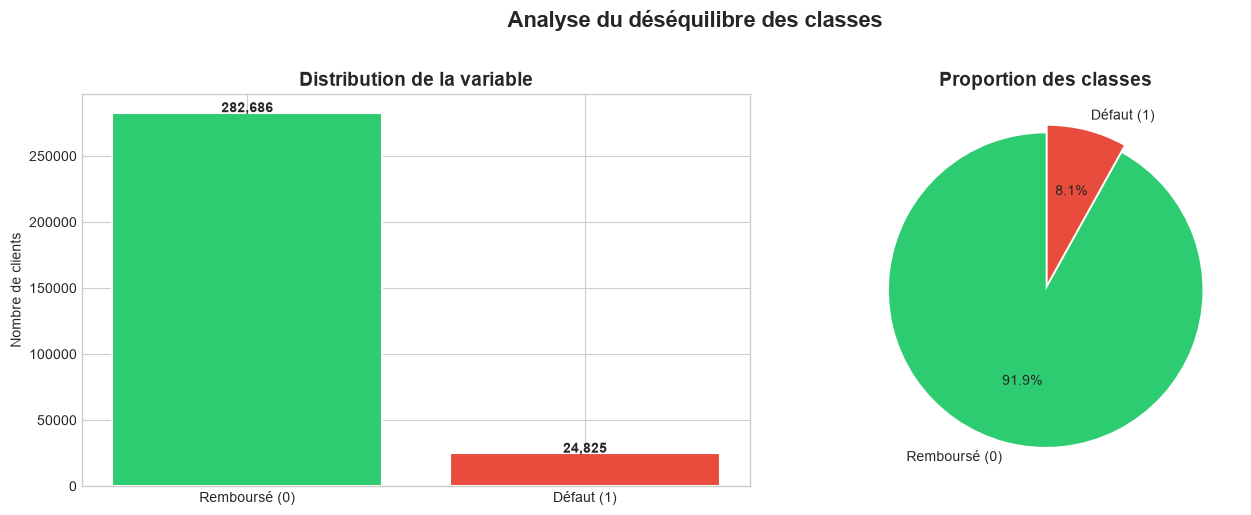


Taux de défaut : 8.07%
Ratio déséquilibré : 1 défaut pour 11 bons clients


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

target_counts = df['TARGET'].value_counts()
axes[0].bar(['Remboursé (0)', 'Défaut (1)'],
            target_counts.values,
            color=['#2ecc71', '#e74c3c'],
            edgecolor='white',
            linewidth=1.5)
axes[0].set_title('Distribution de la variable',
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('Nombre de clients')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')


axes[1].pie(target_counts.values,
            labels=['Remboursé (0)', 'Défaut (1)'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%',
            startangle=90,
            explode=(0, 0.05))
axes[1].set_title('Proportion des classes',
                  fontsize=14, fontweight='bold')

plt.suptitle('Analyse du déséquilibre des classes',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/Users/thierrymanuelzibiondobo/credit_scoring_project/images/01_target_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTaux de défaut : {df['TARGET'].mean()*100:.2f}%")
print(f"Ratio déséquilibré : 1 défaut pour {int(target_counts[0]/target_counts[1])} bons clients")

missing = pd.DataFrame({
    'Valeurs manquantes': df.isnull().sum(),
    'Pourcentage (%)': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Pourcentage (%)', ascending=False)

missing_significant = missing[missing['Pourcentage (%)'] > 0]

print(f"Variables avec valeurs manquantes : {len(missing_significant)}")
print(missing_significant.head(20).to_string())

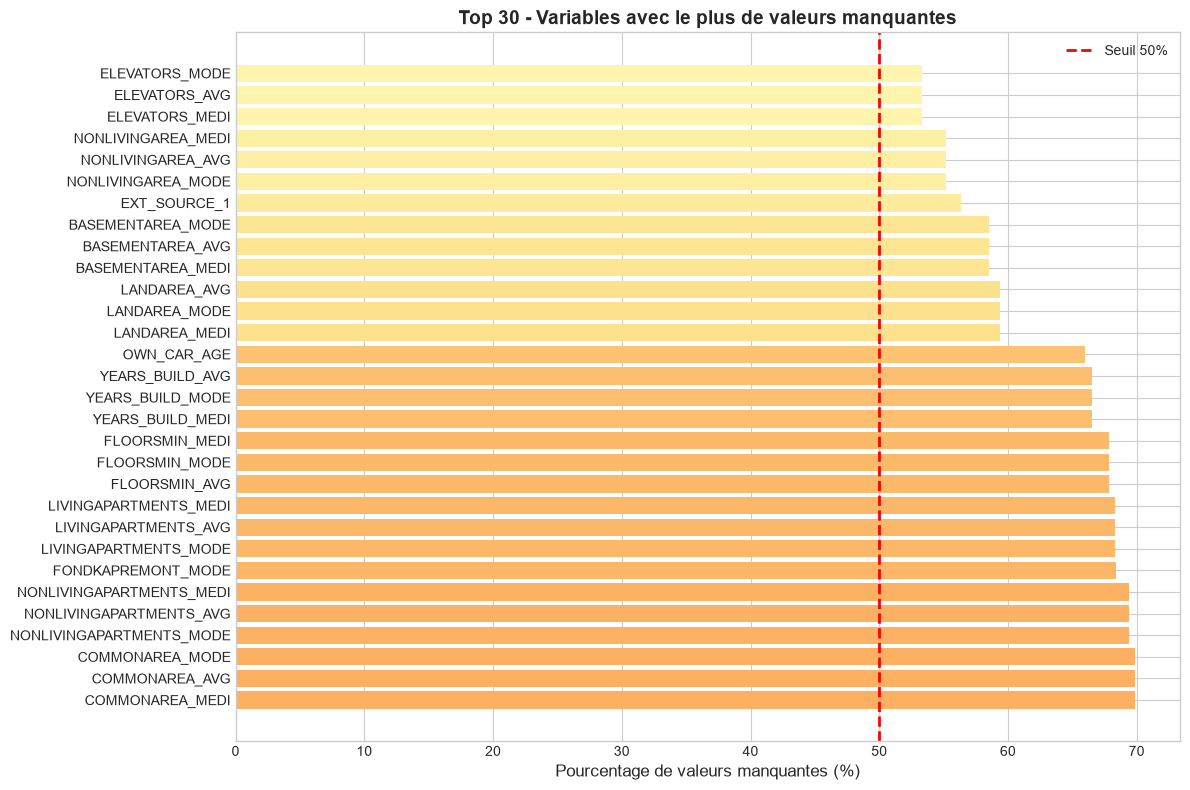

In [18]:
top_missing = missing_significant.head(30)

plt.figure(figsize=(12, 8))
bars=plt.barh(top_missing.index,
              top_missing['Pourcentage (%)'],
              color=plt.cm.RdYlGn_r(top_missing['Pourcentage (%)']/100))
plt.xlabel('Pourcentage de valeurs manquantes (%)', fontsize=12)
plt.title('Top 30 - Variables avec le plus de valeurs manquantes',
          fontsize=14, fontweight='bold')
plt.axvline(x=50, color='red', linestyle='--',
            linewidth=2, label='Seuil 50%')
plt.legend()
plt.tight_layout()
plt.savefig('/Users/thierrymanuelzibiondobo/credit_scoring_project/images/02_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()              
              

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


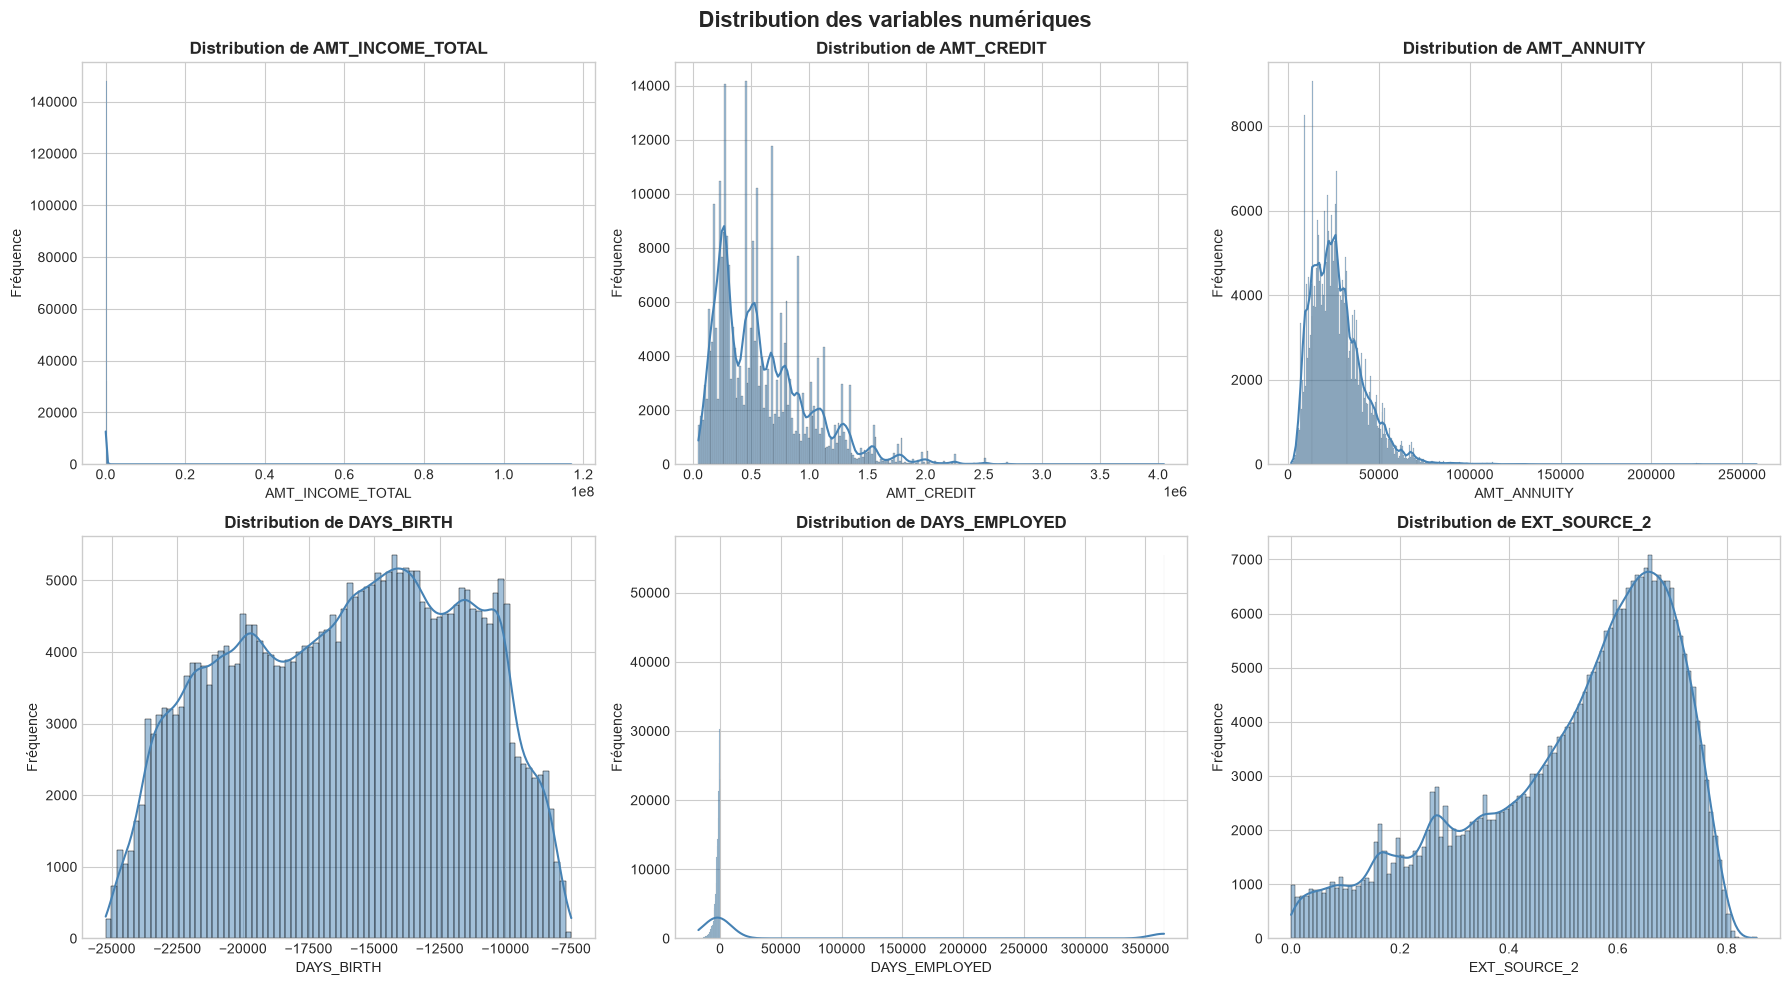

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

variables = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'EXT_SOURCE_2',]

for i, col in enumerate(variables):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution de {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Fréquence')

plt.suptitle('Distribution des variables numériques',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/thierrymanuelzibiondobo/credit_scoring_project/images/03_distributions.png', dpi=150, bbox_inches='tight')
plt.show()




In [21]:
print(df['DAYS_EMPLOYED'].describe())
print(f"\nValeur max : {df['DAYS_EMPLOYED'].max():,}")
print(f"Combien de fois la valeur 365243 apparaît : {(df['DAYS_EMPLOYED'] == 365243).sum():,}")

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

Valeur max : 365,243
Combien de fois la valeur 365243 apparaît : 55,374


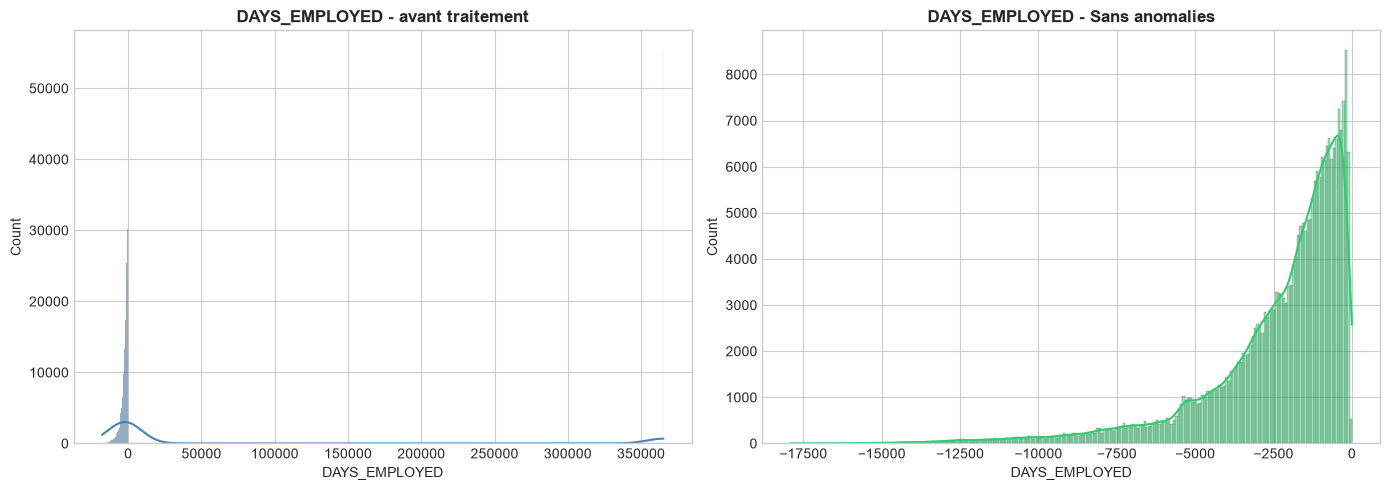

Clients concernés : 55,374
Pourcentage : 18.0%


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='DAYS_EMPLOYED', kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('DAYS_EMPLOYED - avant traitement', fontweight='bold')

df_clean = df[df['DAYS_EMPLOYED'] != 365243]
sns.histplot(data=df_clean, x='DAYS_EMPLOYED', kde=True, ax=axes[1], color='#2ecc71')
axes[1].set_title('DAYS_EMPLOYED - Sans anomalies', fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/thierrymanuelzibiondobo/credit_scoring_project/images/04_days_employed_anomaly.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Clients concernés : {(df['DAYS_EMPLOYED'] == 365243).sum():,}")
print(f"Pourcentage : {(df['DAYS_EMPLOYED'] == 365243).mean()*100:.1f}%")

ANOMALIE DÉTECTÉE : DAYS_EMPLOYED == 365243 pour 55 374 clients (18%)
Ces clients sont probablement retraités ou sans emploi
Traitement prévu : remplacer par NaN + créer variable indicatrice

Nombre de variables numériques : 106
TARGET                         1.000000
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
DAYS_REGISTRATION              0.041975
OWN_CAR_AGE                    0.037612
LIVE_CITY_NOT_WORK_CITY        0.032518
DEF_30_CNT_SOCIAL_CIRCLE       0.032248
DEF_60_CNT_SOCIAL_CIRCLE       0.031276
FLAG_WORK_PHONE                0.028524
AMT_REQ_CREDIT_BUREAU_YEAR     0.019930
CNT_CHILDREN                   0.019187
CNT_FAM_MEMBERS                0.009308
OBS_30_CNT_SOCIAL_CIRCLE       0.009131
Name: TARGET, dtype: float64


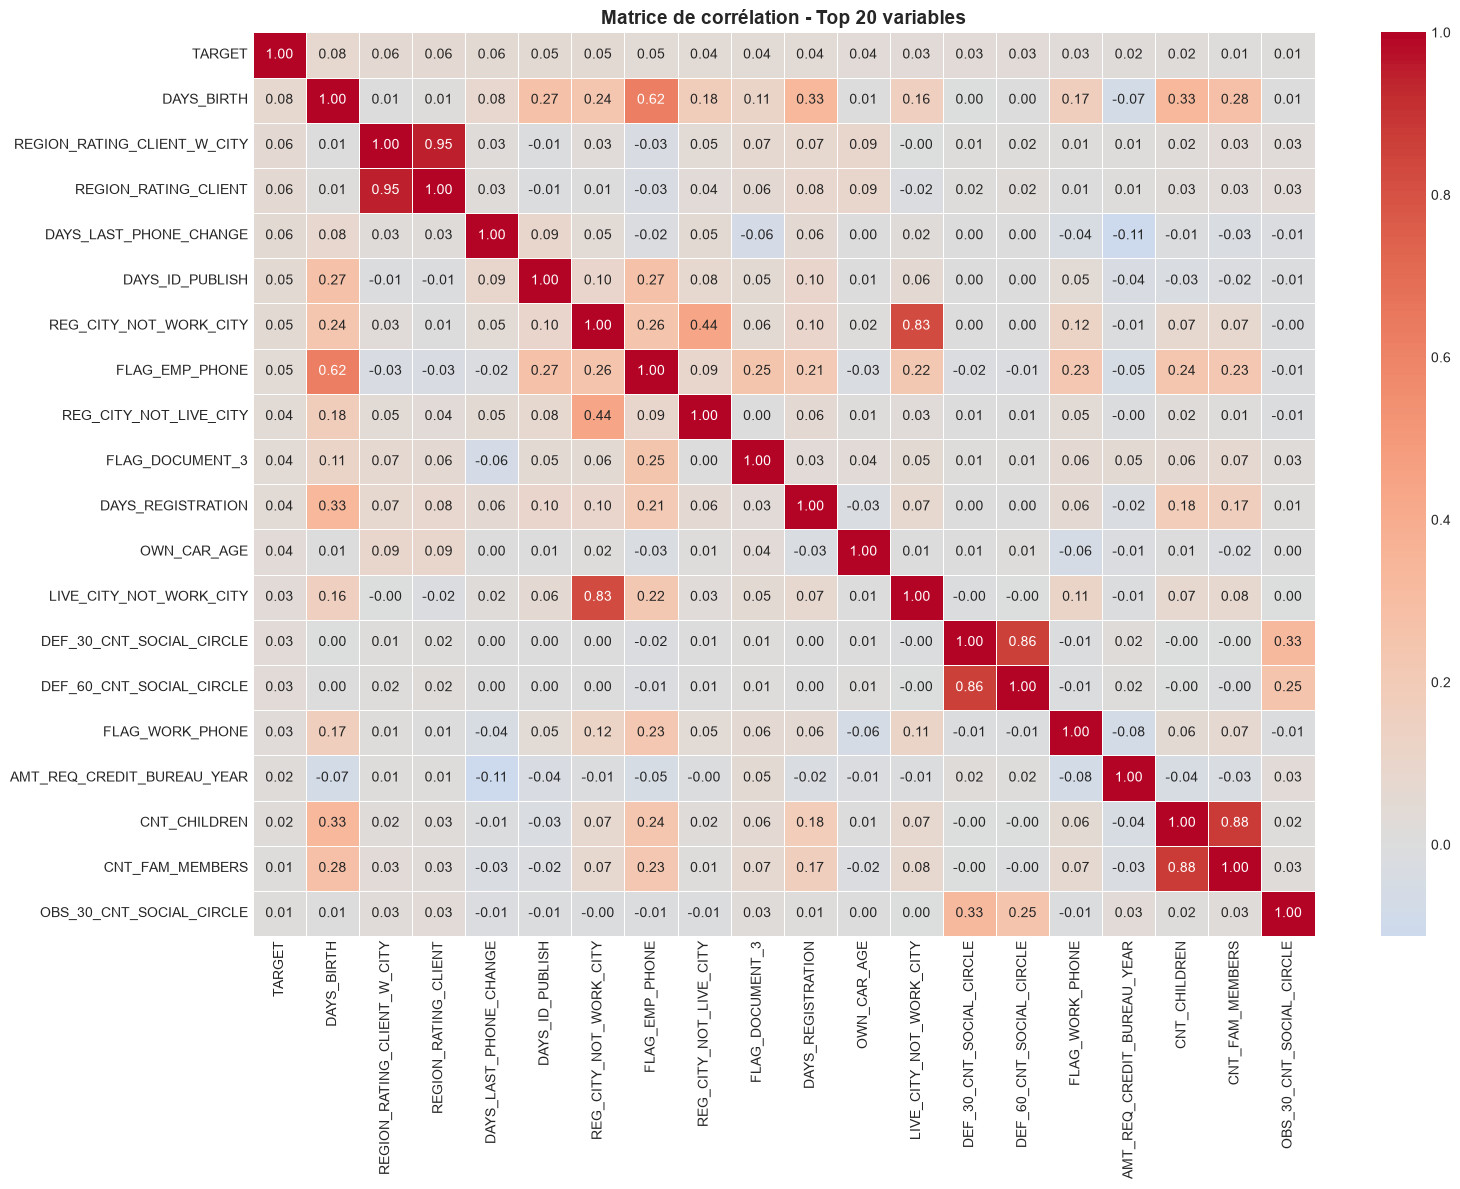

In [27]:
numeric_cols =  df.select_dtypes(include='number').columns.tolist()
print(f"Nombre de variables numériques : {len(numeric_cols)}")

corr_target = df[numeric_cols].corr()['TARGET'].sort_values(ascending=False)
print(corr_target.head(20))

top_cols = corr_target.head(20).index.tolist()

corr_matrix = df[top_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5)
plt.title('Matrice de corrélation - Top 20 variables',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/thierrymanuelzibiondobo/credit_scoring_project/images/05_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# OBSERVATIONS CORRÉLATION :
# - TARGET faiblement corrélé avec toutes les variables individuellement
# - REGION_RATING_CLIENT et REGION_RATING_CLIENT_W_CITY : corrélation 0.95 → redondance
# - REG_CITY_NOT_LIVE_CITY et REG_CITY_NOT_WORK_CITY : corrélation 0.83 → redondance
# - EXT_SOURCE non visible ici → à analyser séparément

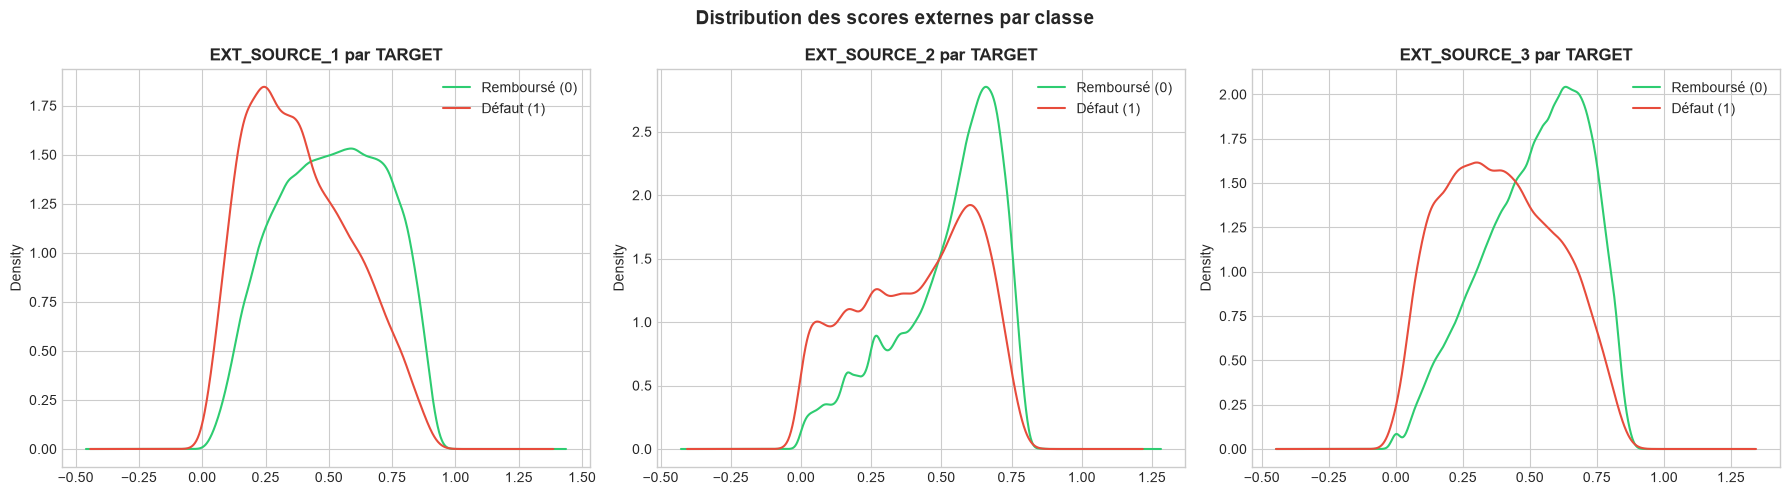

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    # Distribution séparée par TARGET
    df[df['TARGET']==0][col].dropna().plot.kde(ax=axes[i], 
                                                label='Remboursé (0)',
                                                color='#2ecc71')
    df[df['TARGET']==1][col].dropna().plot.kde(ax=axes[i], 
                                                label='Défaut (1)',
                                                color='#e74c3c')
    axes[i].set_title(f'{col} par TARGET', fontweight='bold')
    axes[i].legend()

plt.suptitle('Distribution des scores externes par classe', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/thierrymanuelzibiondobo/credit_scoring_project/images', dpi=150, bbox_inches='tight')
plt.show()

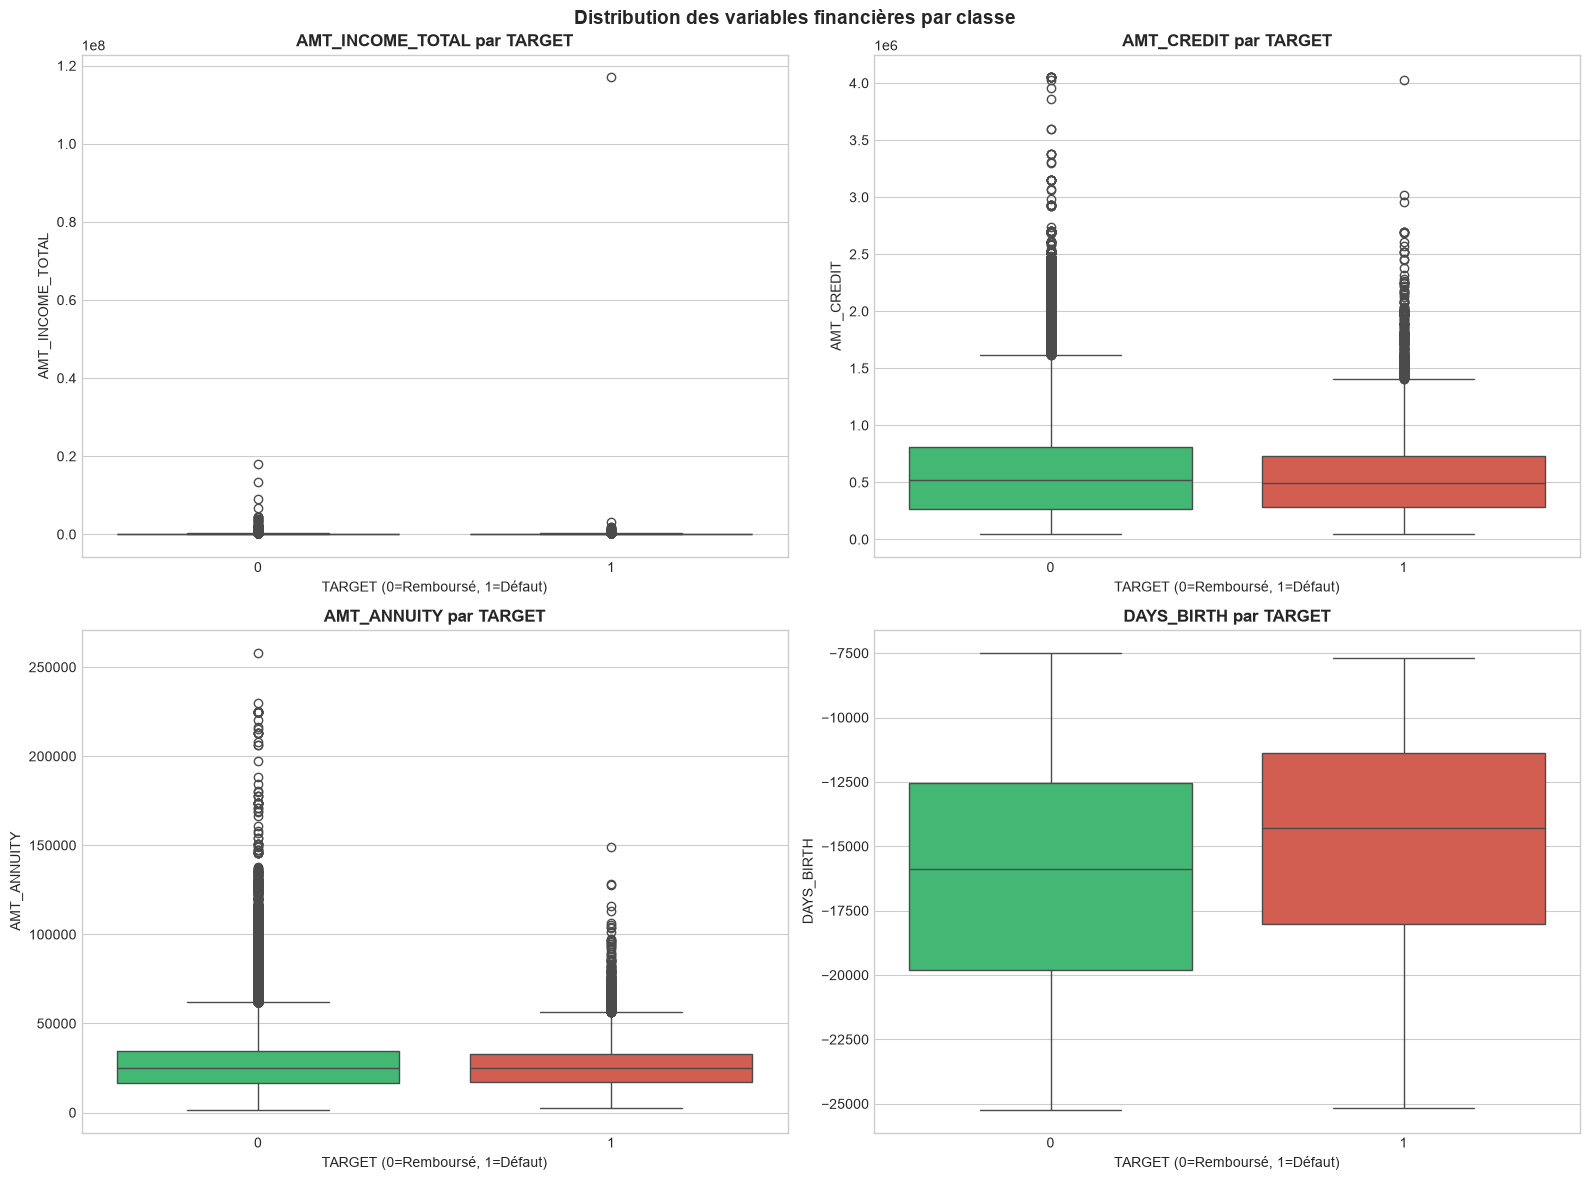

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

variables_box = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'DAYS_BIRTH'
]

for i, col in enumerate(variables_box):
    sns.boxplot(data=df, 
                x='TARGET', 
                y=col,
                palette={'0': '#2ecc71', '1': '#e74c3c'},
                ax=axes[i])
    axes[i].set_title(f'{col} par TARGET', fontweight='bold')
    axes[i].set_xlabel('TARGET (0=Remboursé, 1=Défaut)')
    axes[i].set_ylabel(col)

plt.suptitle('Distribution des variables financières par classe',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/thierrymanuelzibiondobo/credit_scoring_project/images/07_boxplots.png',
            dpi=150, bbox_inches='tight')
plt.show()

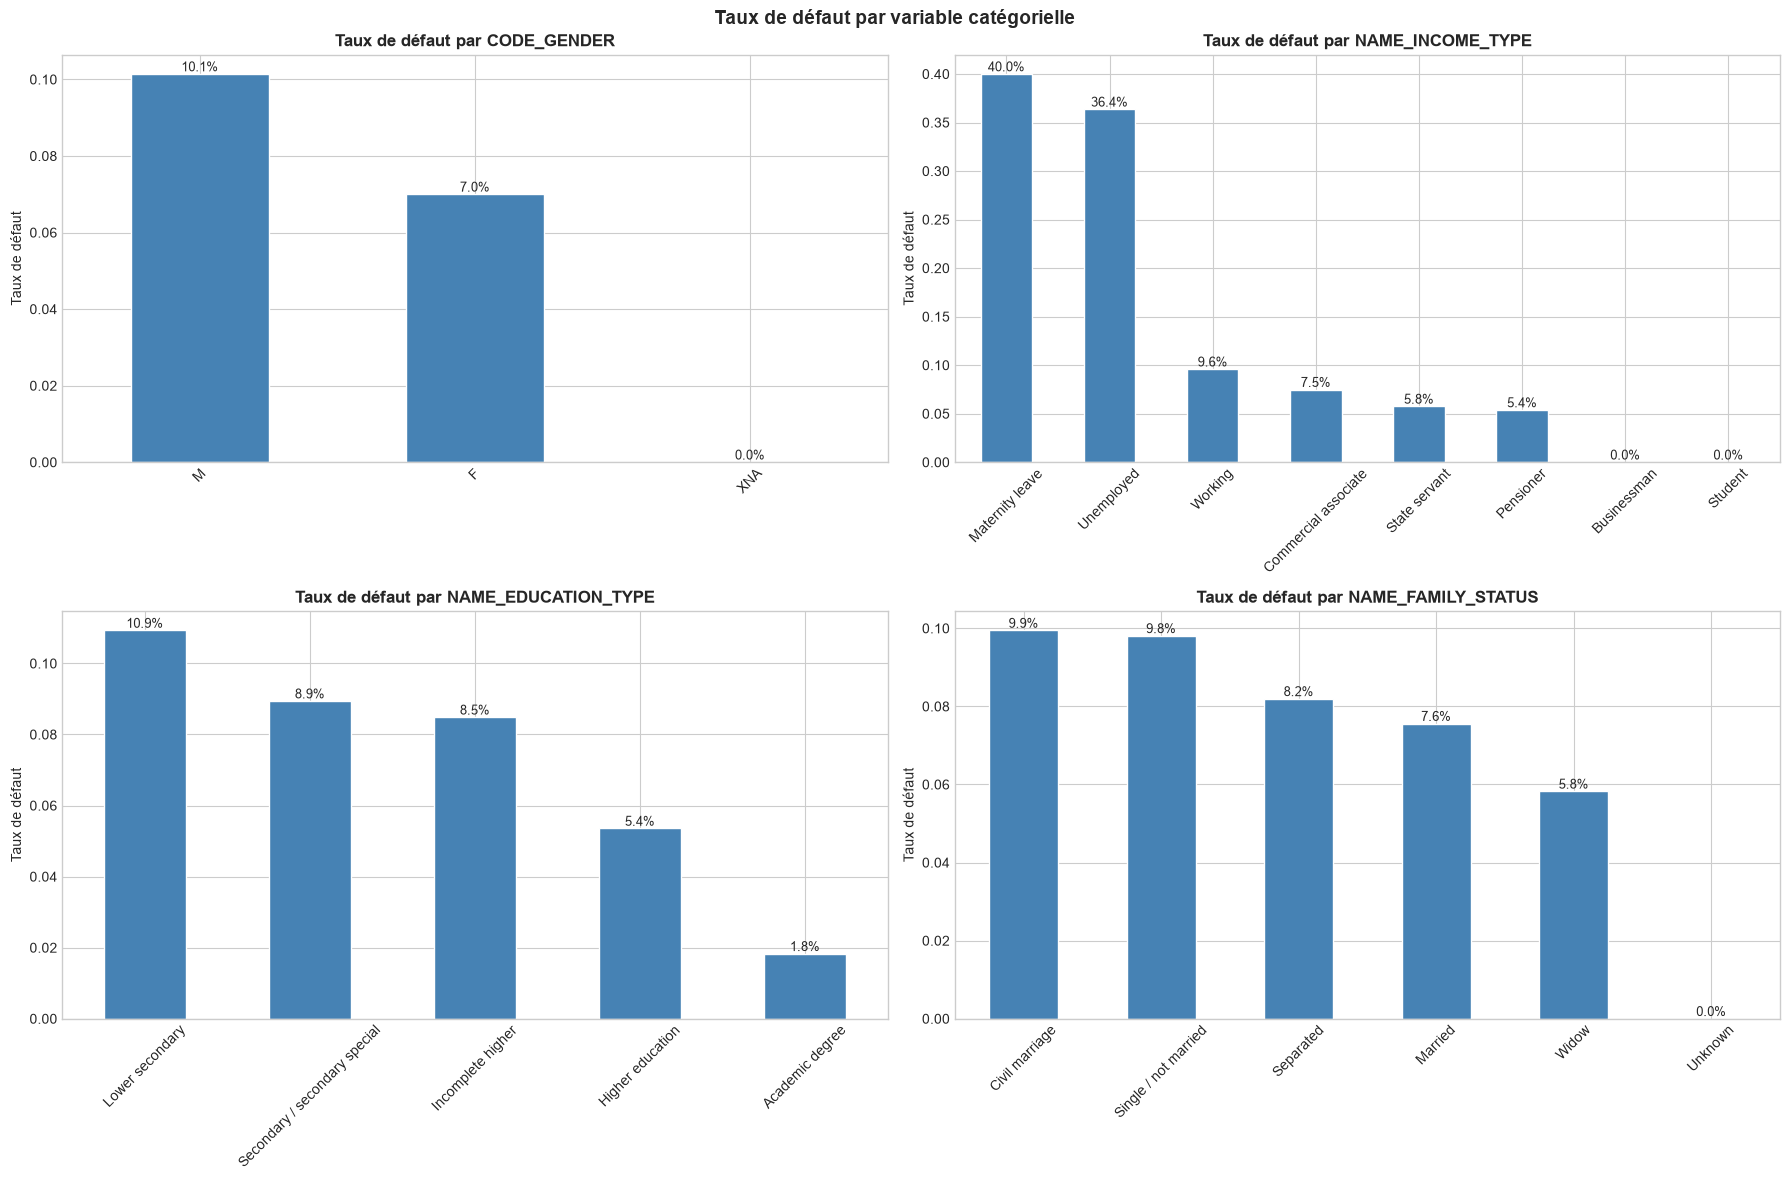

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

variables_cat = [
    'CODE_GENDER',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS'
]

for i, col in enumerate(variables_cat):
    # Calcule le taux de défaut par catégorie
    taux_defaut = df.groupby(col)['TARGET'].mean().sort_values(ascending=False)
    
    taux_defaut.plot(kind='bar', ax=axes[i],
                     color='steelblue', edgecolor='white')
    axes[i].set_title(f'Taux de défaut par {col}', fontweight='bold')
    axes[i].set_ylabel('Taux de défaut')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Ajoute les valeurs sur chaque barre
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.1%}',
                        (p.get_x() + p.get_width()/2, p.get_height()),
                        ha='center', va='bottom', fontsize=9)

plt.suptitle('Taux de défaut par variable catégorielle',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/Users/thierrymanuelzibiondobo/credit_scoring_project/images/08_default_rate_by_category.png',
            dpi=150, bbox_inches='tight')
plt.show()
